# Frequent Pattern Mining: Research Subfields in Highly-Cited Papers
Denise Godinez 

---

## Research Question
Using the OpenAlex works and works_topics tables, we aim to identify which subfields and combinations of subfields are most frequently associated with highly-cited research published between 2020 and 2025.

For each highly-cited paper, we look at the subfields assigned to it by OpenAlex and model them:
- Transaction = one published paper
- Item = a research subfield

We then apply the Apriori algorithm from mlxtend to discover frequent subfield combinations and generate association rules.

---
## Step 1: Imports & Configuration

In [1]:
import pandas as pd
import pyarrow.parquet as pq
from pathlib import Path
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_colwidth', 80)

# Path to the OpenAlex parquet 
BASE_PATH = Path("/data/shared/OpenAlex/processed-snapshots")
PARQUET_PATH = BASE_PATH / "parquet-files" / "may-2025"

# minimum citations for a paper to be considered "highly cited" 
CITATION_THRESHOLD = 50   
MIN_YEAR = 2020           
MAX_YEAR = 2025  
# minimum amount of papers a subfield/pair must appear in
MIN_SUPPORT = 0.01  

---
## Step 2: Load Highly-Cited Works
Use push-down predicates to read only the rows we need from the large works parquet table. We are looking for papers published between 2020–2025 with at least 10 citations.

In [2]:
print("Loading works...")

works_df = pd.read_parquet(
    PARQUET_PATH / 'works',
    # Only load the columns we actually need
    columns=['work_id', 'title', 'publication_year', 'cited_by_count'],
    filters=[
        [
            ('publication_year', '>=', MIN_YEAR),
            ('publication_year', '<=', MAX_YEAR),
            # highly cited papers only
            ('cited_by_count', '>=', CITATION_THRESHOLD),
            # complete metadata required
            ('has_complete_institution_info', '==', True),
            # must have keyword tags
            ('has_keywords', '==', True),                      
        ]
    ],
)

print(f"Loaded {len(works_df):,} highly-cited works")
works_df.head()

Loading works...
Loaded 447,927 highly-cited works


,work_id,title,publication_year,cited_by_count
0,4223541591,A comprehensive review on the adsorption of heavy metals by zeolite imidazol...,2022,184
1,3025854696,Self-harm with suicidal and non-suicidal intent in young people in sub-Sahar...,2020,67
2,2047643587,Songs and Musicians in the Fifteenth Century,2024,86
3,2909533002,Similarity and Self-Esteem in Downward Comparison,2024,175
4,11595491,Visual Search and Reading: Eye Movements and Functional Visual Field: A Tuto...,2022,83


---
## Step 3: Load Topic Data for Those Works
Fetch rows from the works_topics table that correspond to the papers loaded above.

In [3]:
# Convert to list
work_ids = list(works_df.work_id)
print(f"Fetching topics for {len(work_ids):,} works...")

works_topics_df = pd.read_parquet(
    PARQUET_PATH / 'works_topics',
    # Only load rows matching the work_ids
    filters=[['work_id', 'in', work_ids]],
)

print(f"Loaded {len(works_topics_df):,} topic rows")
print(f"Columns: {list(works_topics_df.columns)}")
works_topics_df.head(10)

Fetching topics for 447,927 works...
Loaded 1,324,674 topic rows
Columns: ['work_id', 'publication_year', 'is_primary_topic', 'score', 'topic_id', 'topic_name', 'subfield_id', 'subfield_name', 'field_id', 'field_name', 'domain_id', 'domain_name']


,work_id,publication_year,is_primary_topic,score,topic_id,topic_name,subfield_id,subfield_name,field_id,field_name,domain_id,domain_name
0,4223541591,2022,True,0.9999,10096,Metal-Organic Frameworks: Synthesis and Applications,1604,Inorganic Chemistry,16,Chemistry,3,Physical Sciences
1,4223541591,2022,False,0.9896,10016,Adsorption and biosorption for pollutant removal,2312,Water Science and Technology,23,Environmental Science,3,Physical Sciences
2,4223541591,2022,False,0.9780,12038,Covalent Organic Framework Applications,2505,Materials Chemistry,25,Materials Science,3,Physical Sciences
3,3025854696,2020,True,0.9999,10376,Suicide and Self-Harm Studies,3203,Clinical Psychology,32,Psychology,2,Social Sciences
4,3025854696,2020,False,0.9861,10182,Child and Adolescent Psychosocial and Emotional Development,3203,Clinical Psychology,32,Psychology,2,Social Sciences
5,3025854696,2020,False,0.9546,10272,Mental Health Treatment and Access,3207,Social Psychology,32,Psychology,2,Social Sciences
6,2047643587,2024,True,0.7900,12409,Reformation and Early Modern Christianity,1202,History,12,Arts and Humanities,2,Social Sciences
7,2047643587,2024,False,0.7768,14469,Renaissance Literature and Culture,1205,Classics,12,Arts and Humanities,2,Social Sciences
8,2047643587,2024,False,0.7056,13556,Historical Influence and Diplomacy,3320,Political Science and International Relations,33,Social Sciences,2,Social Sciences
9,4395566315,2021,True,0.7977,12281,Animal testing and alternatives,3404,Small Animals,34,Veterinary,4,Health Sciences


---
## Step 4: Inspect the Topic Score Distribution
We do this to understand how strongly topics are associated with papers before deciding whether to apply a score threshold.

count    1.324674e+06
mean     9.904533e-01
std      3.007721e-02
min      1.070000e-02
25%      9.908000e-01
50%      9.976000e-01
75%      9.996000e-01
max      1.000000e+00
Name: score, dtype: float64


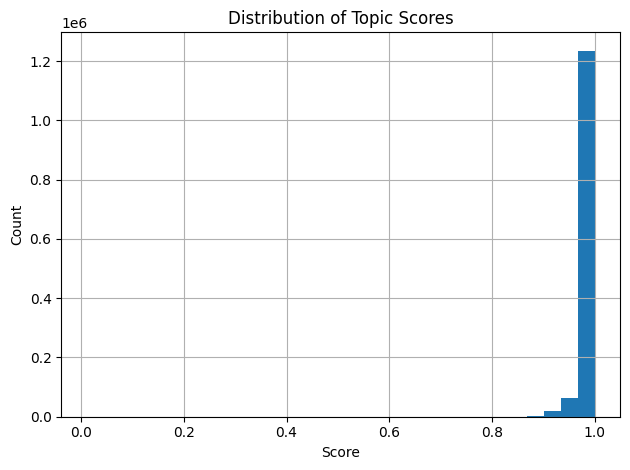

In [4]:
# Summary statistics
print(works_topics_df['score'].describe())

# Plot the distribution to visually check skew and decide on a score threshold
works_topics_df['score'].hist(bins=30)
plt.title("Distribution of Topic Scores")
plt.xlabel("Score")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

---
## Step 5: Build Transactions
- Each paper is a transaction
- Each research subfield assigned to that paper is an item

We use subfield_name rather than topic_name because subfields appear frequently enough across papers to produce meaningful support values. Papers with fewer than 2 subfields are dropped since they cannot contribute to co-occurrence patterns.

In [5]:
# No score threshold applied
# so all assignments are included regardless of score
strong_topics_df = works_topics_df.copy()

# Group by paper 
# Each paper is assigned to its groups of subfields
work_topics = (
    strong_topics_df
    .groupby('work_id')['subfield_name']
    .apply(set)
)

# Drop papers with fewer than 2 subfields
work_topics = work_topics[work_topics.apply(len) >= 2]

print(f"Papers with >=2 subfields: {len(work_topics):,}")

# Convert to list-of-lists (mlxtend format)
transactions = [list(topics) for topics in work_topics]

print("\nSample transaction:")
print(transactions[0])

Papers with >=2 subfields: 409,681

Sample transaction:
['Experimental and Cognitive Psychology', 'Social Psychology', 'Applied Psychology']


---
## Step 6: Sample for Memory Efficiency
With many transactions, building a full boolean matrix would make the kernel crash. A random sample of 100,000 papers is enough to return meaningful data. 

In [6]:
import random

# 100k papers is enough 
SAMPLE_SIZE = 100_000 

# Fix the seed so re-running this cell gives the same sample every time
random.seed(42)
if len(transactions) > SAMPLE_SIZE:
    transactions = random.sample(transactions, SAMPLE_SIZE)

print(f"Working with {len(transactions):,} transactions")
print(f"Sample transaction: {transactions[0]}")

Working with 100,000 transactions
Sample transaction: ['Strategy and Management', 'Sociology and Political Science']


---
## Step 7: Encode Transactions as a Boolean Matrix
TransactionEncoder converts the list-of-lists into a boolean DataFrame where:
- Rows = papers (transactions)
- Columns = unique subfields (items)
- Values = True if that subfield appears in that paper

In [7]:
# First learn all unique subfields, then one-hot encode each transaction
te = TransactionEncoder()
te_array = te.fit_transform(transactions)

# Wrap in a DataFrame
te_df = pd.DataFrame(te_array, columns=te.columns_)

print(f"Matrix shape: {te_df.shape}")
print(f"  {te_df.shape[0]:,} rows  (papers / transactions)")
print(f"  {te_df.shape[1]:,} cols  (unique subfields / items)")

sparsity = (~te_df).sum().sum() / te_df.size
print(f"\nSparsity: {sparsity:.3%} of values are False")
print(f"Column dtype (item keys): {te_df.columns.dtype}")

te_df.head(3)

Matrix shape: (100000, 240)
  100,000 rows  (papers / transactions)
  240 cols  (unique subfields / items)

Sparsity: 98.926% of values are False
Column dtype (item keys): str


,Accounting,Acoustics and Ultrasonics,Aerospace Engineering,Aging,Agronomy and Crop Science,Algebra and Number Theory,Analytical Chemistry,Anatomy,Anesthesiology and Pain Medicine,Animal Science and Zoology,...,Surgery,"Tourism, Leisure and Hospitality Management",Toxicology,Transplantation,Transportation,Urban Studies,Urology,Virology,Visual Arts and Performing Arts,Water Science and Technology
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


---
## Step 8: Run Apriori — Find Frequent Itemsets
Using Apriori finds all subfield combinations whose support meets our minimum threshold:

We use min_support = 0.01 (1% of papers). We chose 0.01 because it's enough to capture meaningful pairs without introducing much noise.

In [8]:
# a subfield or pair must appear in at least 1% of sampled papers
MIN_SUPPORT = 0.01 

print(f"Running Apriori (min_support={MIN_SUPPORT})...")
frequent_itemsets = apriori(
    te_df,
    min_support=MIN_SUPPORT,
    # label itemsets with subfield names, not column indices
    use_colnames=True,   
    verbose=1,
)

# Add a length column to easily filter singles, pairs, triples
frequent_itemsets['length'] = frequent_itemsets['itemsets'].apply(len)

print(f"Found {len(frequent_itemsets):,} frequent itemsets")

# Sort by length first, then by support descending within each length group
frequent_itemsets = frequent_itemsets.sort_values(
    ['length', 'support'], ascending=[True, False]
)

print("Frequent itemsets by size:")
print(frequent_itemsets['length'].value_counts().sort_index().to_string())

print("\nTop 10 frequent subfield PAIRS (length = 2):")
frequent_itemsets[frequent_itemsets['length'] == 2][['support', 'itemsets']].head(10)

Running Apriori (min_support=0.01)...
Processing 123 combinations | Sampling itemset size 32
Found 83 frequent itemsets
Frequent itemsets by size:
length
1    70
2    13

Top 10 frequent subfield PAIRS (length = 2):


,support,itemsets
79,0.02760,"frozenset({Electrical and Electronic Engineering, Materials Chemistry})"
80,0.02488,"frozenset({Renewable Energy, Sustainability and the Environment, Electrical ..."
82,0.02482,"frozenset({Renewable Energy, Sustainability and the Environment, Materials C..."
74,0.01798,"frozenset({Biomedical Engineering, Materials Chemistry})"
78,0.01449,"frozenset({Electronic, Optical and Magnetic Materials, Electrical and Electr..."
75,0.01380,"frozenset({Biomedical Engineering, Mechanical Engineering})"
77,0.01366,"frozenset({Molecular Biology, Cancer Research})"
71,0.01286,"frozenset({Automotive Engineering, Electrical and Electronic Engineering})"
73,0.01166,"frozenset({Biomedical Engineering, Electrical and Electronic Engineering})"
76,0.01132,"frozenset({Molecular Biology, Biomedical Engineering})"


In [15]:
# Testing five different support thresholds
for threshold in [0.005, 0.01, 0.02, 0.05, 0.1]:
    fi = apriori(te_df, min_support=threshold, use_colnames=True, verbose=0)
    print(f"min_support = {threshold:.3f}  →  {len(fi):>5,} frequent itemsets")

min_support = 0.005  →    161 frequent itemsets
min_support = 0.010  →     83 frequent itemsets
min_support = 0.020  →     46 frequent itemsets
min_support = 0.050  →      7 frequent itemsets
min_support = 0.100  →      4 frequent itemsets


---
## Step 9: Generate Association Rules

In [10]:
rules = association_rules(
    frequent_itemsets,
    metric='lift',
    # only keep rules where lift > 1 (above-chance co-occurrence)
    min_threshold=1.0,         
    num_itemsets=len(frequent_itemsets),
)

print(f"Generated {len(rules):,} association rules")

# Sort by lift
# Highest lift = most surprising/interesting co-occurrences
rules.sort_values('lift', ascending=False).head(10)

Generated 22 association rules


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
19,frozenset({Computer Vision and Pattern Recognition}),frozenset({Artificial Intelligence}),0.02969,0.05331,0.01064,0.358370,6.722375,1.0,0.009057,1.475445,0.877290,0.147043,0.322238,0.278979
18,frozenset({Artificial Intelligence}),frozenset({Computer Vision and Pattern Recognition}),0.05331,0.02969,0.01064,0.199587,6.722375,1.0,0.009057,1.212262,0.899178,0.147043,0.175096,0.278979
12,frozenset({Molecular Biology}),frozenset({Cancer Research}),0.12393,0.02155,0.01366,0.110224,5.114780,1.0,0.010989,1.099658,0.918292,0.103626,0.090627,0.372049
13,frozenset({Cancer Research}),frozenset({Molecular Biology}),0.02155,0.12393,0.01366,0.633875,5.114780,1.0,0.010989,2.392815,0.822207,0.103626,0.582082,0.372049
14,frozenset({Automotive Engineering}),frozenset({Electrical and Electronic Engineering}),0.02773,0.11842,0.01286,0.463758,3.916211,1.0,0.009576,1.643996,0.765889,0.096481,0.391726,0.286177
15,frozenset({Electrical and Electronic Engineering}),frozenset({Automotive Engineering}),0.11842,0.02773,0.01286,0.108597,3.916211,1.0,0.009576,1.090718,0.844678,0.096481,0.083173,0.286177
9,"frozenset({Electronic, Optical and Magnetic Materials})",frozenset({Electrical and Electronic Engineering}),0.03484,0.11842,0.01449,0.415901,3.512086,1.0,0.010364,1.509300,0.741088,0.104417,0.337441,0.269131
8,frozenset({Electrical and Electronic Engineering}),"frozenset({Electronic, Optical and Magnetic Materials})",0.11842,0.03484,0.01449,0.122361,3.512086,1.0,0.010364,1.099723,0.811349,0.104417,0.090680,0.269131
4,"frozenset({Renewable Energy, Sustainability and the Environment})",frozenset({Materials Chemistry}),0.07326,0.10980,0.02482,0.338793,3.085550,1.0,0.016776,1.346326,0.729340,0.156850,0.257238,0.282420
5,frozenset({Materials Chemistry}),"frozenset({Renewable Energy, Sustainability and the Environment})",0.10980,0.07326,0.02482,0.226047,3.085550,1.0,0.016776,1.197412,0.759277,0.156850,0.164865,0.282420


---
## Step 10: Add Symmetric Metrics

In [21]:
def cosine_metric(row):
    # Mean of the two directional confidences (symmetric)
    return row['support'] / (row['antecedent support'] * row['consequent support']) ** 0.5

def kulczynski_metric(row):
    conf_ac = row['confidence']                             # P(B | A)
    conf_ca = row['support'] / row['consequent support']   # P(A | B)
    return 0.5 * (conf_ac + conf_ca)                       # average of both directions

def jaccard_metric(row):
    union = row['antecedent support'] + row['consequent support'] - row['support']
    return row['support'] / union

# Apply both metrics to every rule
rules['cosine']     = rules.apply(cosine_metric, axis=1)
rules['jaccard']    = rules.apply(jaccard_metric, axis=1)
rules['kulczynski'] = rules.apply(kulczynski_metric, axis=1)

print("Top rules by Kulczynski (most robust symmetric metric):")
(
    rules
    .sort_values('kulczynski', ascending=False)
    [['antecedents', 'consequents', 'support', 'confidence', 'lift', 'cosine', 'jaccard', 'kulczynski']]
    .head(10)
)

Top rules by Kulczynski (most robust symmetric metric):


,antecedents,consequents,support,confidence,lift,cosine,jaccard,kulczynski
13,frozenset({Cancer Research}),frozenset({Molecular Biology}),0.01366,0.633875,5.114780,0.264325,0.103626,0.372049
12,frozenset({Molecular Biology}),frozenset({Cancer Research}),0.01366,0.110224,5.114780,0.264325,0.103626,0.372049
14,frozenset({Automotive Engineering}),frozenset({Electrical and Electronic Engineering}),0.01286,0.463758,3.916211,0.224416,0.096481,0.286177
15,frozenset({Electrical and Electronic Engineering}),frozenset({Automotive Engineering}),0.01286,0.108597,3.916211,0.224416,0.096481,0.286177
4,"frozenset({Renewable Energy, Sustainability and the Environment})",frozenset({Materials Chemistry}),0.02482,0.338793,3.085550,0.276737,0.156850,0.282420
5,frozenset({Materials Chemistry}),"frozenset({Renewable Energy, Sustainability and the Environment})",0.02482,0.226047,3.085550,0.276737,0.156850,0.282420
19,frozenset({Computer Vision and Pattern Recognition}),frozenset({Artificial Intelligence}),0.01064,0.358370,6.722375,0.267444,0.147043,0.278979
18,frozenset({Artificial Intelligence}),frozenset({Computer Vision and Pattern Recognition}),0.01064,0.199587,6.722375,0.267444,0.147043,0.278979
2,"frozenset({Renewable Energy, Sustainability and the Environment})",frozenset({Electrical and Electronic Engineering}),0.02488,0.339612,2.867863,0.267119,0.149161,0.274856
3,frozenset({Electrical and Electronic Engineering}),"frozenset({Renewable Energy, Sustainability and the Environment})",0.02488,0.210100,2.867863,0.267119,0.149161,0.274856


---
## Step 11: Visualization — Top 15 Most Frequent Subfields
A horizontal bar chart of the 15 subfields with the highest individual support. The chart shows which research areas appear most often among highly-cited papers. Bars are annotated with exact support values.

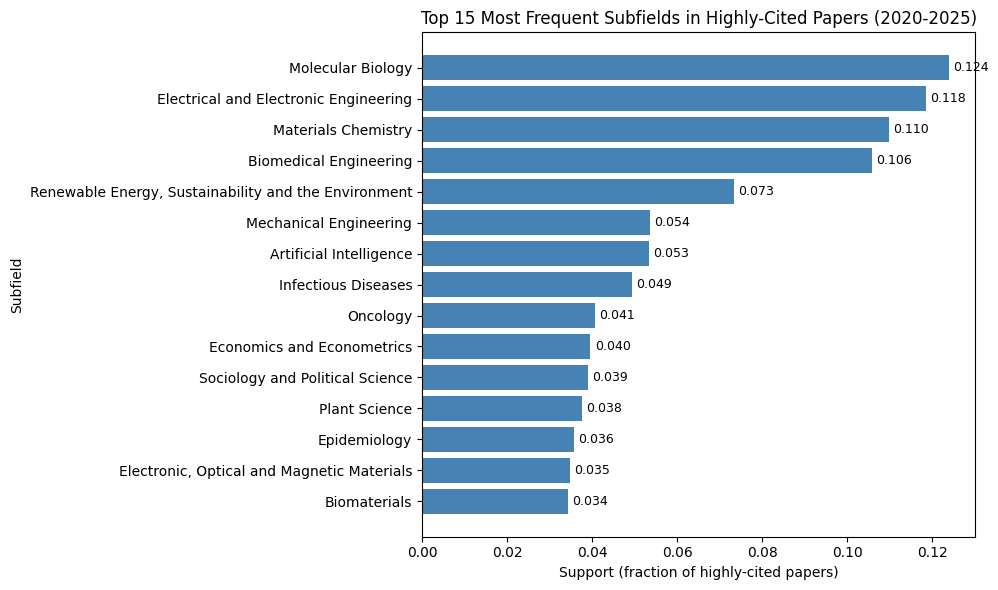

In [12]:
# Get single-item itemsets and pull the subfield name out of the frozenset
top_singles = (
    frequent_itemsets[frequent_itemsets['length'] == 1]
    .copy()
)
top_singles['subfield'] = top_singles['itemsets'].apply(lambda x: list(x)[0])
top_singles = top_singles.sort_values('support', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(top_singles['subfield'], top_singles['support'], color='steelblue')

# Annotate each bar with its exact support value
for bar, val in zip(bars, top_singles['support']):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

ax.set_xlabel("Support (fraction of highly-cited papers)")
ax.set_ylabel("Subfield")
ax.set_title("Top 15 Most Frequent Subfields in Highly-Cited Papers (2020-2025)")
ax.invert_yaxis()  # highest support at the top
plt.tight_layout()
plt.show()

---
## Step 12: Visualization — Frequent Subfield Pairs
A bar chart of all frequent pairs of subfields. Each bar represents a combination of two subfields that co-appear in at least 1% of highly-cited papers.

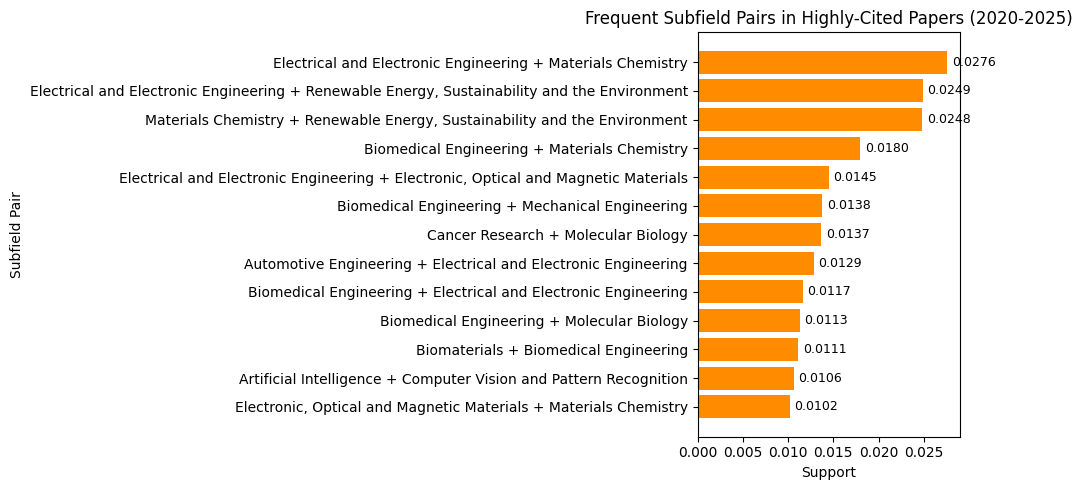

In [13]:
# Get length 2 itemsets and format each pair
pairs = (
    frequent_itemsets[frequent_itemsets['length'] == 2]
    .copy()
)
pairs['pair'] = pairs['itemsets'].apply(lambda x: ' + '.join(sorted(list(x))))
pairs = pairs.sort_values('support', ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(pairs['pair'], pairs['support'], color='darkorange')

# Annotate each bar with its exact support value
for bar, val in zip(bars, pairs['support']):
    ax.text(bar.get_width() + 0.0005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

ax.set_xlabel("Support")
ax.set_ylabel("Subfield Pair")
ax.set_title("Frequent Subfield Pairs in Highly-Cited Papers (2020-2025)")
ax.invert_yaxis()  # most frequent pair at the top
plt.tight_layout()
plt.show()

---
## Step 13: Visualization — Scatter Plots

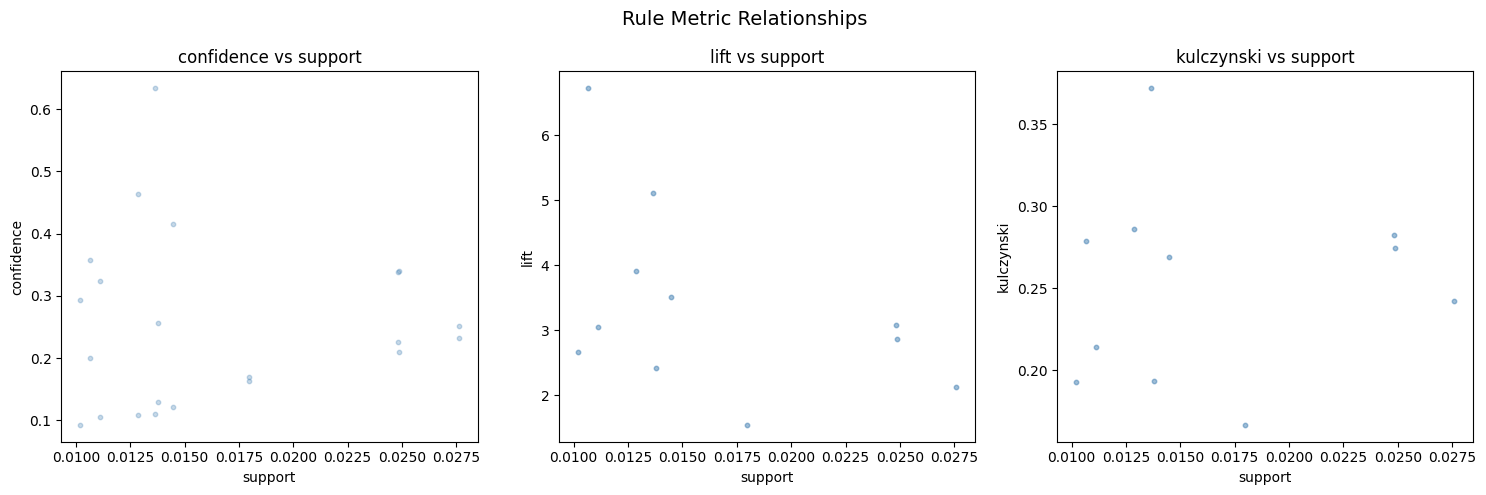

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, y_metric in zip(axes, ['confidence', 'lift', 'kulczynski']):
    ax.scatter(rules['support'], rules[y_metric],
               alpha=0.3, s=10, color='steelblue')
    ax.set_xlabel('support')
    ax.set_ylabel(y_metric)
    ax.set_title(f'{y_metric} vs support')

plt.suptitle("Rule Metric Relationships", fontsize=14)
plt.tight_layout()
plt.show()

---
## Step 14: Interpret Top Rules
Print the most interesting rules ranked by lift and confidence.

- High lift = the two subfields co-occur far more than chance
- High confidence = when the antecedent subfield appears, the consequent almost always does too

In [20]:
def fmt_set(s):
    # Convert a frozenset of subfield names into a readable string
    return ', '.join(sorted(s))

# Build the top 15 rules sorted by kulczynski 
top_rules = (
    rules
    .sort_values('kulczynski', ascending=False)
    .head(15)
    # Include all metrics for comparison
    [['antecedents', 'consequents', 'support', 'confidence',
      'lift', 'cosine', 'jaccard', 'kulczynski']]
    .reset_index(drop=True)
    .copy()
)

# Convert frozensets to readable strings so the table is readable
top_rules['antecedents'] = top_rules['antecedents'].apply(fmt_set)
top_rules['consequents'] = top_rules['consequents'].apply(fmt_set)

# Create a styled table 
# Blue gradient highlights strongest lift and kulczynski values (most interesting)
# Format each metric column to a consistent number of decimal places
top_rules.style.background_gradient(
    subset=['lift', 'kulczynski'], cmap='Blues'
).format({
    'support':    '{:.4f}',  
    'confidence': '{:.3f}',
    'lift':       '{:.2f}',
    'cosine':     '{:.3f}',
    'jaccard':    '{:.3f}',
    'kulczynski': '{:.3f}',
})

,antecedents,consequents,support,confidence,lift,cosine,jaccard,kulczynski
0,Cancer Research,Molecular Biology,0.0137,0.634,5.11,0.264,0.104,0.372
1,Molecular Biology,Cancer Research,0.0137,0.110,5.11,0.264,0.104,0.372
2,Automotive Engineering,Electrical and Electronic Engineering,0.0129,0.464,3.92,0.224,0.096,0.286
3,Electrical and Electronic Engineering,Automotive Engineering,0.0129,0.109,3.92,0.224,0.096,0.286
4,"Renewable Energy, Sustainability and the Environment",Materials Chemistry,0.0248,0.339,3.09,0.277,0.157,0.282
5,Materials Chemistry,"Renewable Energy, Sustainability and the Environment",0.0248,0.226,3.09,0.277,0.157,0.282
6,Computer Vision and Pattern Recognition,Artificial Intelligence,0.0106,0.358,6.72,0.267,0.147,0.279
7,Artificial Intelligence,Computer Vision and Pattern Recognition,0.0106,0.200,6.72,0.267,0.147,0.279
8,"Renewable Energy, Sustainability and the Environment",Electrical and Electronic Engineering,0.0249,0.340,2.87,0.267,0.149,0.275
9,Electrical and Electronic Engineering,"Renewable Energy, Sustainability and the Environment",0.0249,0.210,2.87,0.267,0.149,0.275
